In [2]:
#Libraries and Modules
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
#Load PCA Dataset
df_pca = pd.read_csv("pca_dataset.csv")

In [4]:
#Feature Seperation
PC = df_pca.drop(
    columns=["target_actual"]
)

In [5]:
#Elbow Method
k_values = []
inertia_values = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters = i,
        random_state = 42,
        n_init = 10
    )
    clusters = kmeans.fit(PC)
    score = silhouette_score(PC, kmeans.labels_)
    k_values.append(i)
    inertia_values.append(kmeans.inertia_)

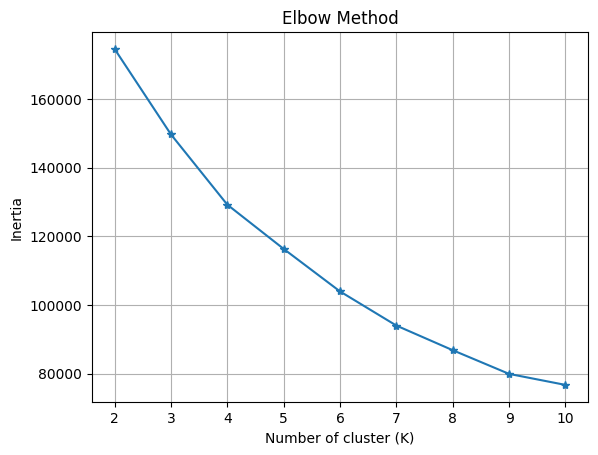

In [6]:
#Elbow Plot
plt.plot(
    k_values, 
    inertia_values,
    marker = '*'
)
plt.xlabel("Number of cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig(
    "screenshots/Elbow Plot", 
    dpi=300,
    bbox_inches="tight"
)
plt.grid(True)

In [8]:
#K-Means (K=2)
kmeans = KMeans(
    n_clusters = 2,
    random_state = 42,
    n_init = 10
)
clusters = kmeans.fit(PC)
df_pca["Clusters"] = kmeans.labels_

In [9]:
#Crosstab
pd.crosstab(
    df_pca["target_actual"], 
    df_pca["Clusters"]
)

Clusters,0,1
target_actual,,
normal breast tissue,0,11
primary breast cancer,58,64


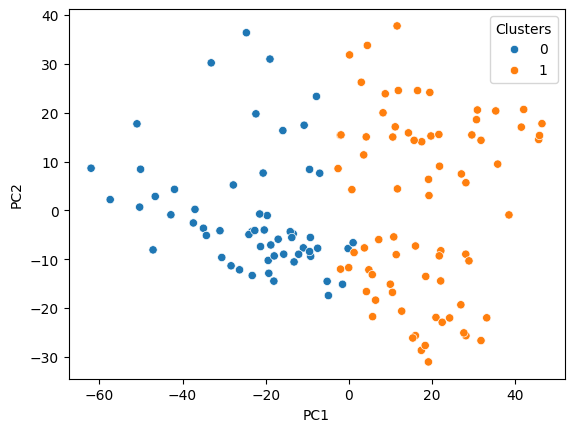

In [10]:
#Cluster Visualization
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Clusters"
)
plt.savefig(
    "screenshots/KMeans cluster visualization",
    dpi=300,
    bbox_inches="tight"
)

In [11]:
#Silhouette Score for k = 2
score = silhouette_score(PC, kmeans.labels_)
score

0.22195475303010875

In [12]:
#Silhoutte score for k = 2-10
scores = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(PC)

    scores.append(
        {
            "K": k,
            "Silhouette score": silhouette_score(
                PC,
                kmeans.labels_
            )
        }
    )

scores_df = pd.DataFrame(scores)

scores_df

,K,Silhouette score
0,2,0.221955
1,3,0.228211
2,4,0.233625
3,5,0.237741
4,6,0.254364
5,7,0.251699
6,8,0.259856
7,9,0.257080
8,10,0.257712


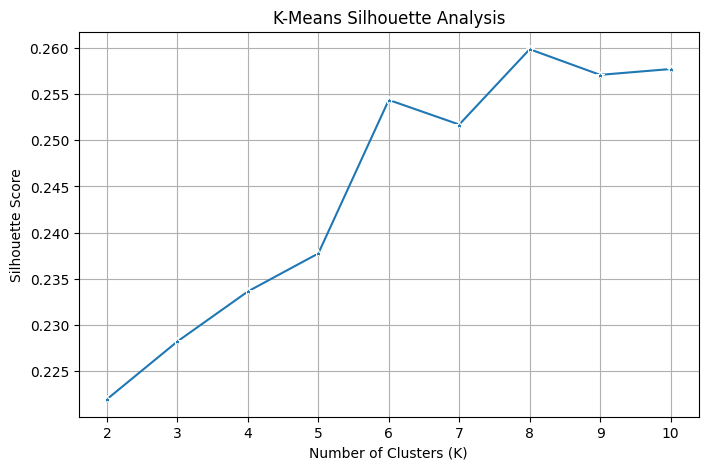

In [14]:
#Silhouette score vs K
plt.figure(figsize=(8,5))

sns.lineplot(
    data=scores_df,
    x="K",
    y="Silhouette score",
    marker="*"
)

plt.title("K-Means Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)
plt.savefig(
    "screenshots/Silhouette vs K plot for KMeans",
    dpi=300,
    bbox_inches="tight"
)
plt.show()